# Example for ray tracing radiological depth.

Imports a patient from a matRad file and visualizes the CT and VOIs with matplotlib. Also produces
a simple beam configuration and visualizes the resulting radiological depth cubes by calling the
RayTracer.

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEBUG:pyRadPlan.optimization.objectives._factory:Objective not found, trying matRad-like objective.


DEBUG:pyRadPlan.optimization.objectives._factory:Objective not found, trying matRad-like objective.


DEBUG:pyRadPlan.optimization.objectives._factory:Objective not found, trying matRad-like objective.


Beam:   0%|          | 0/1 [00:00<?, ?b/s]

...

DEBUG:pyRadPlan.raytracer._siddon:Trace Ray: 41072 rays, 41072 sources, compute_all_alphas: 0.2524s, compute_indices: 0.2014s, finalization: 0.0992s


DEBUG:pyRadPlan.raytracer._base:Cube ray tracing took 0.5582919999724254 seconds...


DEBUG:pyRadPlan.raytracer._base:Found 2473729 ray indices for radiological depth calculation (took 0.25825249997433275 seconds)


DEBUG:pyRadPlan.raytracer._base:Radiological depth cube filling took 0.09070139995310456 seconds


Minimum rad depth: 0.0Maximum rad depth: 174.76637268066406


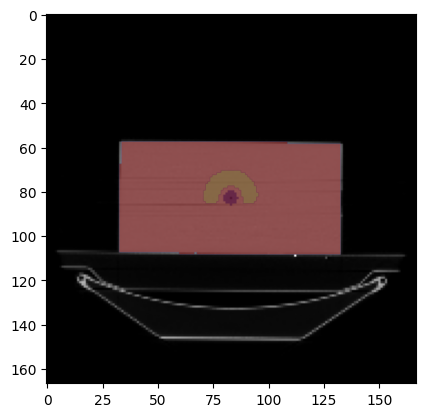

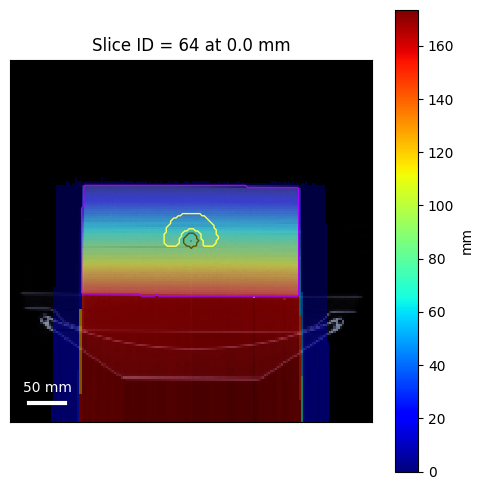

In [1]:
# Standard Library Imports
import logging
import sys

if sys.version_info < (3, 10):
    import importlib_resources as resources  # Backport for older versions
else:
    from importlib import resources  # Standard from Python 3.9+

# Third Party Imports from pyRadPlan requirements

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# pyRadPlan Module Imports
from pyRadPlan.ct import default_hlut
from pyRadPlan.plan import IonPlan
from pyRadPlan.stf.generators import StfGeneratorIMPT
from pyRadPlan.raytracer import RayTracerSiddon
from pyRadPlan.visualization import plot_slice
from pyRadPlan.io import load_patient

from pyRadPlan import settings

# Use a GPU backend if one is available (auto-selected), otherwise fall back to the CPU backend
settings.xp.prefer_gpu = True

# Configure the Logger to show you debug information
logging.basicConfig(level=logging.INFO)
logging.getLogger("pyRadPlan").setLevel(logging.DEBUG)

#  Read patient from provided TG119.mat file and validate data
path = resources.files("pyRadPlan.data.phantoms").joinpath("TG119.mat")
ct, cst = load_patient(path)

# Choose a slice to visualize
view_slice = int(np.round(ct.size[2] / 2))

# We store images as sitk.Image objects, but we can easily convert them to numpy arrays for
# matplotlib. Taking a "view" here means we do not perform a deep copy of the image data.
cube_hu = sitk.GetArrayViewFromImage(ct.cube_hu)
plt.imshow(cube_hu[view_slice, :, :], cmap="gray")

# Now let's visualize the VOIs from the StructureSet.
for v, voi in enumerate(cst.vois):
    mask = sitk.GetArrayViewFromImage(voi.mask)
    plt.imshow(
        (v + 1) * mask[view_slice, :, :],
        cmap="jet",
        alpha=0.5 * (mask[view_slice, :, :] > 0),
        vmin=1,
        vmax=len(cst.vois),
    )

# Since we want to do planning, we create a plan object.
# We choose protons as the radiation mode and a Generic machine included with pyRadPlan
pln = IonPlan(radiation_mode="protons", machine="Generic")

# We use the StfGeneratorIMPT to create a simple beam configuration
# with a single beam at 0 degrees
stfgen = StfGeneratorIMPT(pln)
stfgen.bixel_width = 5.0
stfgen.gantry_angles = [0.0]

# We generate the beam geometry on the CT and CST
stf = stfgen.generate(ct, cst)

# Now let's look at the water equivalent path length for our beam.
# For that, we use a default HU->rSP table to convert our CT to water-equivalent thickness and then
# call a voxel-wise RayTracing algorithm (proposed by Siddon) to calculate the radiological depth.
rt = RayTracerSiddon([ct.compute_wet(default_hlut())])
rt.lateral_cut_off = 150.0
rt.precision = np.float32
rt.debug_core_performance = True
rad_depth_cubes = rt.trace_cubes(stf[0])

# We could write the image if we want, but we don't do this by default.
# sitk.WriteImage(ct.compute_wet(default_hlut()), "wet.nrrd")
# sitk.WriteImage(rad_depth_cubes[0], "rad_depth_cubes.nrrd")

# Let's see about our range of radiological depths
rd_np = sitk.GetArrayFromImage(rad_depth_cubes[0])
rd_np.ravel()[np.isnan(rd_np.ravel())] = 0
min_rad_depth = np.min(rd_np)
max_rad_depth = np.nanmax(rd_np)
print(f"Minimum rad depth: {min_rad_depth}Maximum rad depth: {max_rad_depth}")

# Visualize
plot_slice(
    image_volume=ct,
    cst=cst,
    overlay=rd_np,
    view_slice=view_slice,
    plane="axial",
    overlay_unit="mm",
    overlay_rel_threshold=1e-3,
)